HANDWRITTEN DIGIT RECOGNITION
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images : (60000, 28, 28)
Testing Images : (10000, 28, 28)


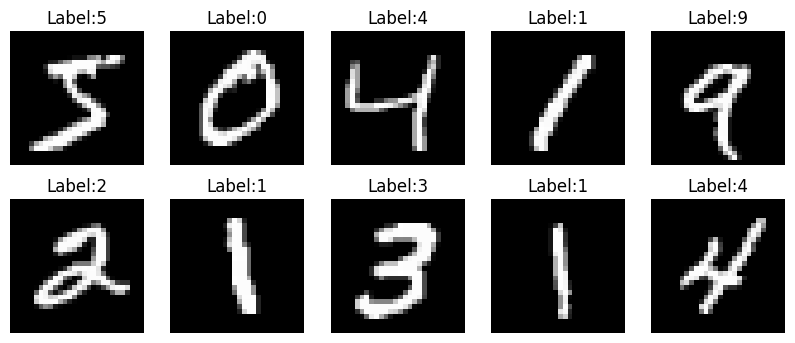

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 55ms/step - accuracy: 0.9310 - loss: 0.2250 - val_accuracy: 0.9813 - val_loss: 0.0659
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.9772 - loss: 0.0741 - val_accuracy: 0.9851 - val_loss: 0.0495
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 54ms/step - accuracy: 0.9841 - loss: 0.0511 - val_accuracy: 0.9888 - val_loss: 0.0393
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.9871 - loss: 0.0410 - val_accuracy: 0.9899 - val_loss: 0.0365
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.9899 - loss: 0.0327 - val_accuracy: 0.9908 - val_loss: 0.0357
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9905 - loss: 0.0268

Test Accuracy : 0.9904999732971191


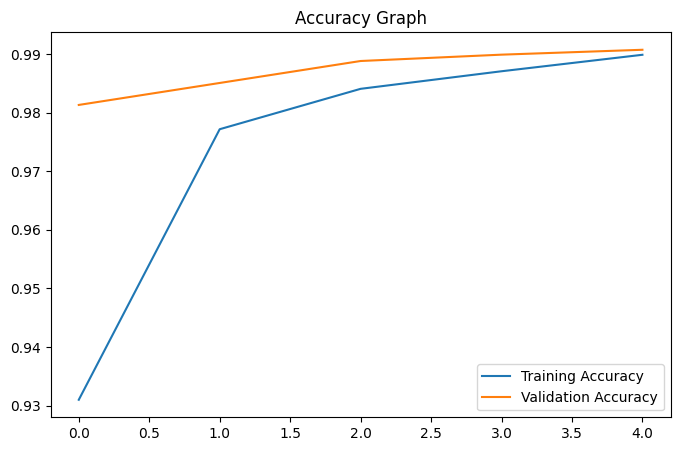

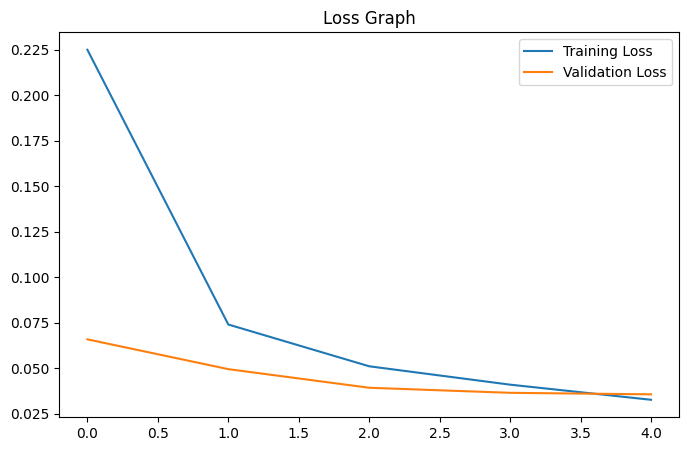

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


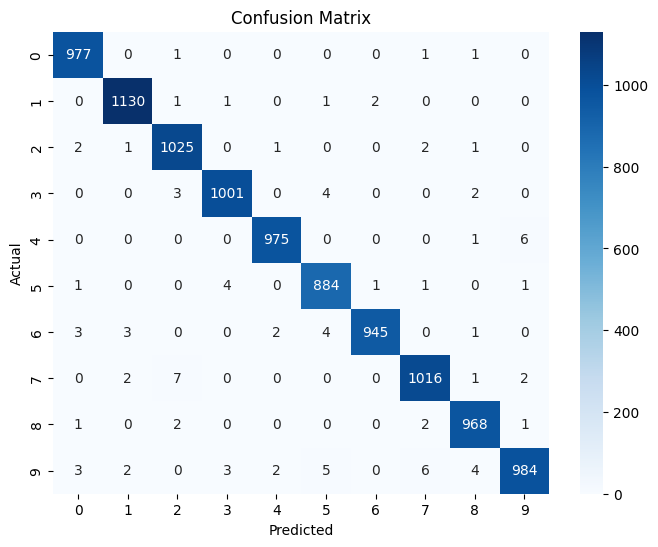

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



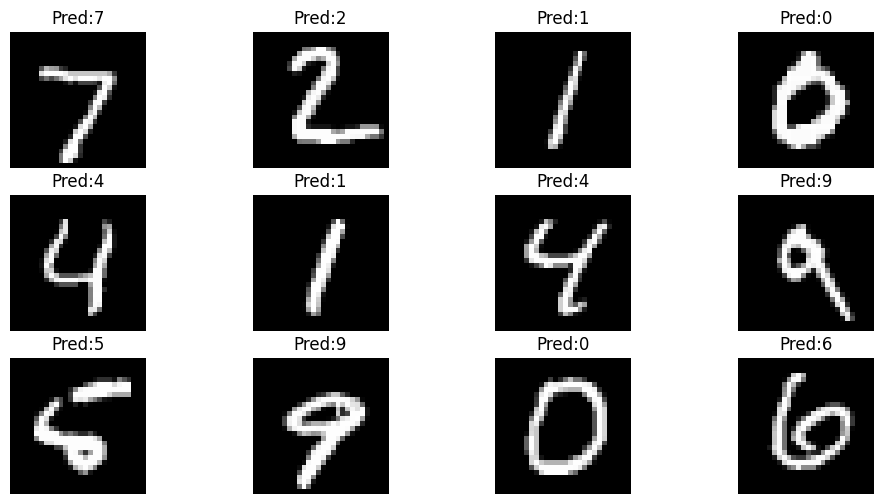


Model Saved Successfully!


In [1]:
!pip -q install tensorflow matplotlib seaborn scikit-learn joblib

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

print("="*60)
print("HANDWRITTEN DIGIT RECOGNITION")
print("="*60)

# Load Dataset
(X_train,y_train),(X_test,y_test)=mnist.load_data()

print("Training Images :",X_train.shape)
print("Testing Images :",X_test.shape)

# Display Sample Images
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i],cmap='gray')
    plt.title("Label:"+str(y_train[i]))
    plt.axis("off")

plt.show()

# Normalize Images
X_train=X_train/255.0
X_test=X_test/255.0

# Reshape
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

# One Hot Encoding
y_train_cat=to_categorical(y_train)
y_test_cat=to_categorical(y_test)

# CNN Model
model=Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(10,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# Train Model
history=model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

# Evaluate
loss,accuracy=model.evaluate(X_test,y_test_cat)

print("\nTest Accuracy :",accuracy)

# Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.legend()
plt.title("Accuracy Graph")
plt.show()

# Loss Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.legend()
plt.title("Loss Graph")
plt.show()

# Predictions
predictions=model.predict(X_test)

pred=np.argmax(predictions,axis=1)

# Confusion Matrix
cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test,pred))

# Display Predictions
plt.figure(figsize=(12,6))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i].reshape(28,28),cmap='gray')
    plt.title("Pred:"+str(pred[i]))
    plt.axis("off")

plt.show()

# Save Model
model.save("handwritten_character_model.h5")

print("\nModel Saved Successfully!")